In [1]:
import pandas as pd
import numpy as np
import pickle

from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

from statsmodels.tsa.arima.model import ARIMA
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [2]:
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../../data/data.csv")

In [4]:
df.head()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Đơn_vị_tính,Loại_tiền,Nguồn,Ngày,Giá,Ngành_hàng
0,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,5/9/2025 12:00:00 AM,128233.0,Cà phê
1,Cà phê Robusta nhân xô,Đắk Nông,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,5/9/2025 12:00:00 AM,128350.0,Cà phê
2,Cà phê Robusta nhân xô,Gia Lai,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,5/9/2025 12:00:00 AM,128233.0,Cà phê
3,Cà phê Robusta nhân xô,Kon Tum,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,5/9/2025 12:00:00 AM,128200.0,Cà phê
4,Cà phê Robusta nhân xô,Lâm Đồng,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,5/9/2025 12:00:00 AM,128000.0,Cà phê


In [5]:
df["Ngày"] = pd.to_datetime(df["Ngày"], format="%m/%d/%Y %I:%M:%S %p")

In [6]:
del df["Loại_tiền"]
del df["Đơn_vị_tính"]

# Trực quan dữ liệu thô

## Tất cả các ngành

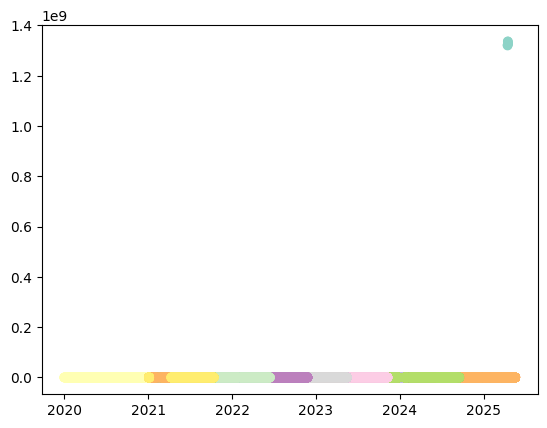

In [7]:
plt.scatter(df["Ngày"], df["Giá"], c=range(len(df)), cmap='Set3')

## Ngành cà phê

In [8]:
caphe_df = df[df["Ngành_hàng"] == "Cà phê"]
caphe_df.head()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá,Ngành_hàng
0,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,CTV địa phương,2025-05-09,128233.0,Cà phê
1,Cà phê Robusta nhân xô,Đắk Nông,Thương lái thu mua,CTV địa phương,2025-05-09,128350.0,Cà phê
2,Cà phê Robusta nhân xô,Gia Lai,Thương lái thu mua,CTV địa phương,2025-05-09,128233.0,Cà phê
3,Cà phê Robusta nhân xô,Kon Tum,Thương lái thu mua,CTV địa phương,2025-05-09,128200.0,Cà phê
4,Cà phê Robusta nhân xô,Lâm Đồng,Thương lái thu mua,CTV địa phương,2025-05-09,128000.0,Cà phê


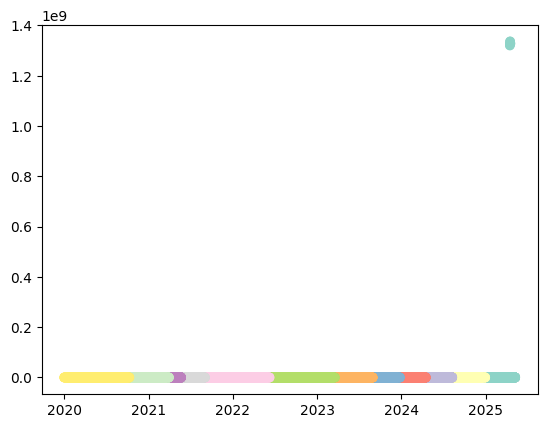

In [9]:
plt.scatter(caphe_df["Ngày"], caphe_df["Giá"], c=range(len(caphe_df)), cmap='Set3')

## Ngành rau quả

In [10]:
rauqua_df = df[df["Ngành_hàng"] == "Rau, quả"]
rauqua_df.head()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá,Ngành_hàng
21895,Bắp cải,Sơn La,Bán lẻ,CTV địa phương,2025-05-19,10000.0,"Rau, quả"
21896,Bắp cải thảo,Sơn La,Bán lẻ,CTV địa phương,2025-05-19,10000.0,"Rau, quả"
21897,Bưởi da xanh,Sơn La,Bán lẻ,CTV địa phương,2025-05-19,35000.0,"Rau, quả"
21898,Bưởi Diễn,Sơn La,Bán lẻ,CTV địa phương,2025-05-19,10000.0,"Rau, quả"
21899,Cà chua,Sơn La,Bán lẻ,CTV địa phương,2025-05-19,12000.0,"Rau, quả"


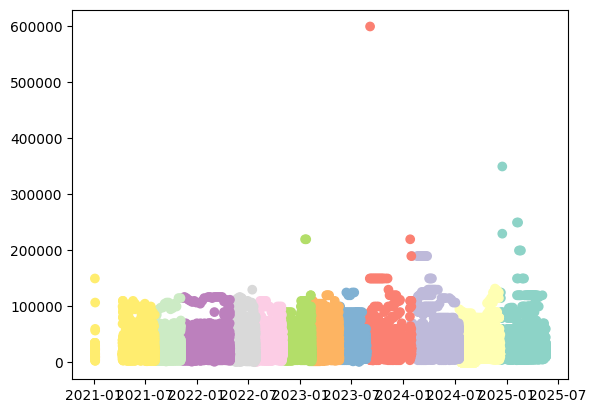

In [11]:
plt.scatter(rauqua_df["Ngày"], rauqua_df["Giá"], c=range(len(rauqua_df)), cmap='Set3')

## Ngành lúa gạo

In [12]:
lugao_df = df[df["Ngành_hàng"] == "Lúa, gạo"]
lugao_df.head()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá,Ngành_hàng
4845,CLC 4900,Cần Thơ,Thương lái thu mua,CTV địa phương,2025-05-19,16000.00,"Lúa, gạo"
4846,IR 5451,Cần Thơ,Thương lái thu mua,CTV địa phương,2025-05-19,7000.00,"Lúa, gạo"
4847,Jasmine,Cần Thơ,Thương lái thu mua,CTV địa phương,2025-05-19,11266.67,"Lúa, gạo"
4848,OM 18,Cần Thơ,Thương lái thu mua,CTV địa phương,2025-05-19,7000.00,"Lúa, gạo"
4849,OM 5451,Cần Thơ,Thương lái thu mua,CTV địa phương,2025-05-19,6000.00,"Lúa, gạo"


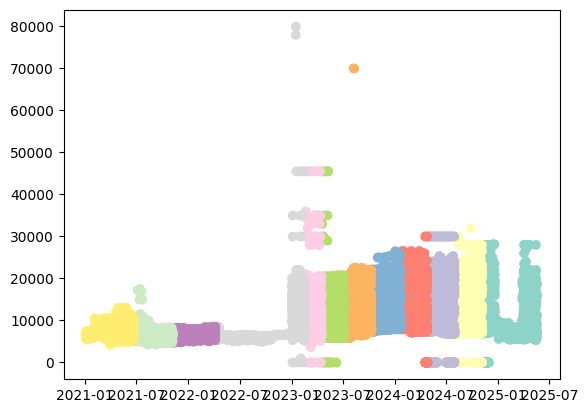

In [13]:
plt.scatter(lugao_df["Ngày"], lugao_df["Giá"], c=range(len(lugao_df)), cmap='Set3')

In [14]:
del df["Ngành_hàng"]

# Kiểm tra dữ liệu thiếu

In [15]:
df.isnull().sum()

Tên_mặt_hàng    0
Thị_trường      0
Loại_giá        0
Nguồn           0
Ngày            0
Giá             0
dtype: int64

# Kiểm tra dữ liệu thừa

In [16]:
df.duplicated().sum()

np.int64(3)

In [17]:
df.drop_duplicates()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá
0,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,CTV địa phương,2025-05-09,128233.0
1,Cà phê Robusta nhân xô,Đắk Nông,Thương lái thu mua,CTV địa phương,2025-05-09,128350.0
2,Cà phê Robusta nhân xô,Gia Lai,Thương lái thu mua,CTV địa phương,2025-05-09,128233.0
3,Cà phê Robusta nhân xô,Kon Tum,Thương lái thu mua,CTV địa phương,2025-05-09,128200.0
4,Cà phê Robusta nhân xô,Lâm Đồng,Thương lái thu mua,CTV địa phương,2025-05-09,128000.0
...,...,...,...,...,...,...
51483,Quýt ngọt Phù Yên,Sơn La,Bán lẻ,CTV địa phương,2021-01-04,35000.0
51484,Rau cải,Sơn La,Bán lẻ,CTV địa phương,2021-01-04,12000.0
51485,Su hào,Sơn La,Bán lẻ,CTV địa phương,2021-01-04,10000.0
51486,Su su quả,Sơn La,Bán lẻ,CTV địa phương,2021-01-04,12000.0


In [18]:
len(df)

51488

# Xoá dữ liệu ngoại lai

In [19]:
import numpy as np

items = df["Tên_mặt_hàng"].unique()

for item in items:
    item_df = df[df["Tên_mặt_hàng"] == item]
    price = item_df["Giá"].values

    q1 = np.quantile(price, 0.25)
    q3 = np.quantile(price, 0.75)
    iqr = q3 - q1

    min_threshold = q1 - 1.5 * iqr
    max_threshold = q3 + 1.5 * iqr

    df = df[~(
        (df["Tên_mặt_hàng"] == item) &
        ((df["Giá"] < max(1000, min_threshold)) | 
        (df["Giá"] > max_threshold))
    )]

In [20]:
df.shape

(48739, 6)

# Kiểm định adf

In [21]:
items = df["Tên_mặt_hàng"].unique()

In [22]:
results_df = pd.DataFrame(columns=["Tên_mặt_hàng", "adf", "p-value", "n_lags", "n_obs", "1%", "5%", "10%"])

for item in items:
    arr = df[df["Tên_mặt_hàng"] == item]["Giá"].dropna().values
    if len(arr) < 3:
        print(f"Mặt hàng '{item}' có quá ít dữ liệu để kiểm định ADF.")
        continue
    if np.all(arr == arr[0]):
        print(f"Giá trị của mặt hàng '{item}' là hằng số.")
        continue
    try:
        results = adfuller(arr)
        temp_df = pd.DataFrame([{
            "Tên_mặt_hàng": item,
            "adf": results[0],
            "p-value": results[1],
            "n_lags": results[2],
            "n_obs": results[3],
            "1%": results[4]["1%"],
            "5%": results[4]["5%"],
            "10%": results[4]["10%"]
        }])
        results_df = pd.concat([results_df, temp_df], axis=0, ignore_index=True)
    except Exception as e:
        print(f"Lỗi khi kiểm định ADF cho mặt hàng '{item}': {e}")


Giá trị của mặt hàng 'ST25' là hằng số.
Giá trị của mặt hàng 'Gạo XK 10% tấm' là hằng số.
Giá trị của mặt hàng 'Ôtin' là hằng số.
Mặt hàng 'Gạo nhóm lúa chất lượng cao (OM18)' có quá ít dữ liệu để kiểm định ADF.
Mặt hàng 'Gạo nhóm lúa chất lượng trung bình (OM 576)' có quá ít dữ liệu để kiểm định ADF.
Mặt hàng 'Gạo nhóm lúa thơm đặc sản (ST24)' có quá ít dữ liệu để kiểm định ADF.
Mặt hàng 'Gạo nhóm lúa thơm đặc sản (ST25)' có quá ít dữ liệu để kiểm định ADF.
Mặt hàng 'Lúa chất lượng cao (OM18)' có quá ít dữ liệu để kiểm định ADF.
Mặt hàng 'Lúa chất lượng trung bình (OM576)' có quá ít dữ liệu để kiểm định ADF.
Mặt hàng 'Lúa thơm đặc sản (ST24)' có quá ít dữ liệu để kiểm định ADF.
Mặt hàng 'Lúa thơm đặc sản (ST25)' có quá ít dữ liệu để kiểm định ADF.
Mặt hàng 'Gạo dài thường' có quá ít dữ liệu để kiểm định ADF.
Mặt hàng 'Gạo tài nguyên' có quá ít dữ liệu để kiểm định ADF.
Mặt hàng 'Gạo thơm thường' có quá ít dữ liệu để kiểm định ADF.
Mặt hàng 'OM 4218' có quá ít dữ liệu để kiểm định ADF.

In [23]:
print(len(results_df))

304


In [39]:
results_df

,Tên_mặt_hàng,adf,p-value,n_lags,n_obs,1%,5%,10%
0,Cà phê Robusta nhân xô,-1.544740,0.511275,31,4786,-3.431717,-2.862144,-2.567092
1,Cà phê Arabica nhân xô,-1.009318,0.749851,5,15,-3.964443,-3.084908,-2.681814
2,CLC 4900,-0.957852,0.768325,6,109,-3.491818,-2.888444,-2.581120
3,Jasmine,-1.002442,0.752373,17,316,-3.451215,-2.870730,-2.571666
4,OM 18,-2.137725,0.229618,12,335,-3.450022,-2.870207,-2.571387
...,...,...,...,...,...,...,...,...
299,Chanh leo,-2.240337,0.191932,0,14,-4.012034,-3.104184,-2.690987
300,Dưa lưới,-2.321087,0.165257,1,9,-4.473135,-3.289881,-2.772382
301,Mận hậu (loại 1),0.963201,0.993862,0,24,-3.737709,-2.992216,-2.635747
302,Dưa hấu (trái dài),-1.288107,0.634596,4,14,-4.012034,-3.104184,-2.690987


In [ ]:
filtered_item = results_df[
    (results_df["p-value"] < 0.05) & 
    (results_df["adf"] < results_df["10%"]) 
]["Tên_mặt_hàng"].values

In [25]:
print(filtered_item[:5])

['Gạo NL 25% tấm' 'Gạo XK 5% tấm' '108' 'Nếp Sáp (Huyện Chợ Gạo- TG)'
 'OM 380']


In [26]:
filtered_df = df[df["Tên_mặt_hàng"].isin(filtered_item)]

In [27]:
filtered_df.head()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá
4865,Gạo NL 25% tấm,Kiên Giang,Thương lái thu mua,CTV địa phương,2025-05-16,8460.0
4869,Gạo XK 5% tấm,Kiên Giang,Thương lái thu mua,CTV địa phương,2025-05-16,10070.0
4900,108,Tiền Giang,Thương lái thu mua,CTV địa phương,2025-05-14,15200.0
4902,Gạo XK 5% tấm,Tiền Giang,Thương lái thu mua,CTV địa phương,2025-05-14,15300.0
4906,Nếp Sáp (Huyện Chợ Gạo- TG),Tiền Giang,Thương lái thu mua,CTV địa phương,2025-05-14,19500.0


In [28]:
len(filtered_df)

10825

# Loại bỏ các mặt hàng dưới 10 dòng

In [29]:
items = filtered_df["Tên_mặt_hàng"].unique()
valid_items = []

for item in items:
    item_df = filtered_df[filtered_df["Tên_mặt_hàng"] == item]
    if len(item_df) >= 10:
        valid_items.append(item)

In [30]:
print(len(valid_items))

53


In [31]:
filtered_df = filtered_df[filtered_df["Tên_mặt_hàng"].isin(valid_items)]
len(filtered_df)

10778

In [32]:
filtered_df.to_csv("../../data/pre_data.csv", index=False)

# Huấn luyện mô hình SARIMA

In [33]:
for col in ["Tên_mặt_hàng", "Thị_trường", "Loại_giá", "Nguồn"]:
    filtered_df[col] = LabelEncoder().fit_transform(filtered_df[col])

In [34]:
for col in ["Tên_mặt_hàng", "Thị_trường", "Loại_giá", "Nguồn"]:
    scaler = MinMaxScaler()  
    filtered_df[col] = scaler.fit_transform(filtered_df[[col]])

    with open(f"../mm_scaler/{col}.pkl", "wb") as file:
        pickle.dump(scaler, file)

In [35]:
filtered_df

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá
4865,0.365385,0.500000,0.714286,0.0,2025-05-16,8460.0
4869,0.384615,0.500000,0.714286,0.0,2025-05-16,10070.0
4902,0.384615,0.785714,0.714286,0.0,2025-05-14,15300.0
4927,0.903846,0.428571,0.714286,0.0,2025-05-13,10650.0
4949,0.365385,0.500000,0.714286,0.0,2025-05-09,8520.0
...,...,...,...,...,...,...
51478,0.711538,0.642857,0.142857,0.0,2021-01-04,25000.0
51479,0.692308,0.642857,0.142857,0.0,2021-01-04,18000.0
51481,0.826923,0.642857,0.142857,0.0,2021-01-04,15000.0
51484,0.846154,0.642857,0.142857,0.0,2021-01-04,12000.0


In [36]:
groups = filtered_df.groupby(["Tên_mặt_hàng", "Thị_trường", "Loại_giá", "Nguồn"])
results = []

for keys, group_df in groups:
    group_df = group_df.sort_values("Ngày")
    
    if len(group_df) < 10:
        continue  # Skip if not enough data

    y = group_df["Giá"]
    exog = group_df[["Tên_mặt_hàng", "Thị_trường", "Loại_giá", "Nguồn"]]

    try:
        model = SARIMAX(y, exog=exog, order=(1,1,1), seasonal_order=(0,0,0,0))
        model_fit = model.fit(disp=False)
        
        # Forecast using the last row of exog
        forecast = model_fit.forecast(steps=1, exog=exog.tail(1))
        results.append((keys, forecast.iloc[0]))

    except Exception as e:
        print(f"Skip group {keys} due to error: {e}")


In [37]:
for keys, predicted_price in results:
    print(f"{keys} → Dự báo giá: {predicted_price}")

(np.float64(0.0), np.float64(0.3571428571428571), np.float64(0.14285714285714285), np.float64(0.0)) → Dự báo giá: 64127.83316571953
(np.float64(0.0), np.float64(0.6428571428571428), np.float64(0.14285714285714285), np.float64(0.0)) → Dự báo giá: 35000.000119677614
(np.float64(0.0), np.float64(0.7857142857142857), np.float64(0.5714285714285714), np.float64(0.0)) → Dự báo giá: 35009.521804255055
(np.float64(0.0), np.float64(0.7857142857142857), np.float64(0.7142857142857142), np.float64(0.0)) → Dự báo giá: 30769.207320362617
(np.float64(0.019230769230769232), np.float64(0.7857142857142857), np.float64(0.5714285714285714), np.float64(0.0)) → Dự báo giá: 21961.98706812936
(np.float64(0.019230769230769232), np.float64(0.7857142857142857), np.float64(0.7142857142857142), np.float64(0.0)) → Dự báo giá: 18748.160826217834
(np.float64(0.038461538461538464), np.float64(0.2857142857142857), np.float64(0.7142857142857142), np.float64(0.0)) → Dự báo giá: 16827.838291185933
(np.float64(0.03846153846

In [38]:
len(results)

116